# TABULA
## Paper: TabuLa: Harnessing Language Models for Tabular Data Synthesis.
## GitHub: https://github.com/zhao-zilong/Tabula



In [1]:
import json, textwrap
from pathlib import Path

def cell_md(s):
    return {"cell_type":"markdown","metadata":{},"source":s.strip()+"\n"}

def cell_code(s):
    return {"cell_type":"code","metadata":{},"source":s.strip()+"\n","execution_count":None,"outputs":[]}

nb = {
  "cells": [],
  "metadata": {
    "kernelspec": {"display_name":"Python 3","language":"python","name":"python3"},
    "language_info": {"name":"python"}
  },
  "nbformat": 4,
  "nbformat_minor": 5
}

nb["cells"].append(cell_md("""
# Run TabuLa (zhao-zilong/Tabula) on Katabatic `car.csv`

This notebook:
1) clones TabuLa repo (if needed)
2) loads Katabatic `car.csv`
3) trains TabuLa (best-effort auto-detection)
4) generates synthetic rows
5) evaluates Accuracy + F1 (TSTR: train on synthetic, test on real)
"""))



In [2]:
import os
import sys
import subprocess
from pathlib import Path

def run(cmd, cwd=None):
    print("\n$", cmd if isinstance(cmd, str) else " ".join(cmd))
    p = subprocess.run(
        cmd,
        cwd=cwd,
        shell=isinstance(cmd, str),
        capture_output=True,
        text=True
    )
    if p.stdout:
        print("--- STDOUT ---\n", p.stdout[-4000:])
    if p.stderr:
        print("--- STDERR ---\n", p.stderr[-4000:])
    if p.returncode != 0:
        raise RuntimeError(f"Command failed (exit {p.returncode}).")
    return p


In [3]:
import os, sys, subprocess, json, textwrap
from pathlib import Path

def run(cmd, cwd=None):
    print("\n$ " + (cmd if isinstance(cmd, str) else " ".join(map(str, cmd))))
    p = subprocess.run(
        cmd,
        cwd=cwd,
        shell=isinstance(cmd, str),
        capture_output=True,
        text=True
    )
    if p.stdout:
        print("--- STDOUT ---\n", p.stdout[:4000])
    if p.stderr:
        print("--- STDERR ---\n", p.stderr[:4000])
    if p.returncode != 0:
        raise RuntimeError(f"Command failed (exit {p.returncode}).")
    return p

KATABATIC_ROOT = Path(r"C:\Users\ROG\Documents\GitHub_T\Katabatic")
TABULA_ROOT    = KATABATIC_ROOT / "katabatic" / "models" / "Tabula"

print("KATABATIC_ROOT:", KATABATIC_ROOT)
print("TABULA_ROOT:", TABULA_ROOT)
print("Tabula package exists:", (TABULA_ROOT / "tabula" / "__init__.py").exists())


KATABATIC_ROOT: C:\Users\ROG\Documents\GitHub_T\Katabatic
TABULA_ROOT: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\Tabula
Tabula package exists: True


In [4]:
# 2) Install dependencies (TabuLa README suggests: datasets, numpy, pandas, sklearn, torch, tqdm, transformers)
run([sys.executable,"-m","pip","install","-U","pip","setuptools","wheel"])
run([sys.executable,"-m","pip","install","-U","numpy","pandas","scikit-learn","tqdm","datasets","transformers"])
"""))

nb["cells"].append(cell_code(r"""


$ C:\Users\ROG\AppData\Local\Programs\Python\Python313\python.exe -m pip install -U pip setuptools wheel
--- STDOUT ---


$ C:\Users\ROG\AppData\Local\Programs\Python\Python313\python.exe -m pip install -U numpy pandas scikit-learn tqdm datasets transformers
--- STDOUT ---


'))\n\nnb["cells"].append(cell_code(r'

In [5]:
# 3) Load car.csv from Katabatic (auto-search common locations)
import pandas as pd

candidate_paths = [
    KATABATIC_ROOT / "raw_data" / "car.csv",
    KATABATIC_ROOT / "sample_data" / "car.csv",
    KATABATIC_ROOT / "discretized_data" / "car.csv",
    KATABATIC_ROOT / "encoded_data" / "car.csv",
]

CAR_CSV = None
for p in candidate_paths:
    if p.exists():
        CAR_CSV = p
        break

print("Detected CAR_CSV:", CAR_CSV)
if CAR_CSV is None:
    raise FileNotFoundError("car.csv not found in common folders. Set CAR_CSV manually to your full path.")

df = pd.read_csv(CAR_CSV)
print("Shape:", df.shape)
display(df.head())

# TabuLa requirement: no spaces in column names
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df = df.dropna().reset_index(drop=True)

# label column (for evaluation): prefer class/label else last column
if "class" in df.columns:
    LABEL_COL = "class"
elif "label" in df.columns:
    LABEL_COL = "label"
else:
    LABEL_COL = df.columns[-1]
print("Using LABEL_COL:", LABEL_COL)
"""))

nb["cells"].append(cell_code(r"""

Detected CAR_CSV: C:\Users\ROG\Documents\GitHub_T\Katabatic\raw_data\car.csv
Shape: (1728, 7)


,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Using LABEL_COL: 6


'))\n\nnb["cells"].append(cell_code(r'

In [6]:
# 4) Split train/test and write CSVs for TabuLa
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df[LABEL_COL] if df[LABEL_COL].nunique() > 1 else None
)
print("Train:", train_df.shape, "Test:", test_df.shape)

WORK_DIR = TABULA_ROOT / "runs" / "car"
WORK_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = WORK_DIR / "car_train.csv"
TEST_CSV  = WORK_DIR / "car_test.csv"
train_df.to_csv(TRAIN_CSV, index=False)
test_df.to_csv(TEST_CSV, index=False)

print("Wrote:", TRAIN_CSV)
print("Wrote:", TEST_CSV)
"""))

nb["cells"].append(cell_code(r"""

Train: (1382, 7) Test: (346, 7)
Wrote: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\Tabula\runs\car\car_train.csv
Wrote: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\Tabula\runs\car\car_test.csv


'))\n\nnb["cells"].append(cell_code(r'

In [7]:
# 5) Import TabuLa (auto-detect trainer/generator class)
import importlib, pkgutil, inspect

sys.path.insert(0, str(TABULA_ROOT))
import tabula  # folder in repo (not tabula-py)

print("tabula package path:", tabula.__file__)

def find_candidate_classes(pkg):
    candidates = []
    pkg_path = Path(pkg.__file__).parent
    for m in pkgutil.iter_modules([str(pkg_path)]):
        modname = f"{pkg.__name__}.{m.name}"
        try:
            mod = importlib.import_module(modname)
        except Exception:
            continue
        for name, obj in inspect.getmembers(mod, inspect.isclass):
            if obj.__module__ != modname:
                continue
            methods = set(dir(obj))
            score = sum(k in methods for k in ["fit","train","sample","generate","synthesize"])
            if "Tabula" in name or score >= 2:
                candidates.append((score, modname, name, obj))
    candidates.sort(reverse=True, key=lambda x: (x[0], x[1], x[2]))
    return candidates

cands = find_candidate_classes(tabula)
print("Top candidates:")
for score, modname, name, _ in cands[:10]:
    print(f"  score={score}  {modname}:{name}")
if not cands:
    raise RuntimeError("Could not auto-detect TabuLa class. Open Tabula_on_insurance_dataset.ipynb and copy its imports/API.")
"""))

nb["cells"].append(cell_code(r"""

C:\Users\ROG\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tabula package path: C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\Tabula\tabula\__init__.py
Top candidates:
  score=2  tabula.tabula:Tabula
  score=1  tabula.tabula_trainer:TabulaTrainer
  score=0  tabula.tabula_start:TabulaStart
  score=0  tabula.tabula_dataset:TabulaDataset
  score=0  tabula.tabula_dataset:TabulaDataCollator


'))\n\nnb["cells"].append(cell_code(r'

In [8]:
import inspect
from tabula.tabula import Tabula

print("Tabula.__init__ signature:")
print(inspect.signature(Tabula.__init__))

print("\nTabula.__init__ source file:")
import tabula.tabula as tabula_mod
print(tabula_mod.__file__)

import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "transformers", "accelerate", "torch"])



Tabula.__init__ signature:
(self, llm: str, experiment_dir: str = 'trainer_tabula', epochs: int = 100, batch_size: int = 8, categorical_columns: list = [], **train_kwargs)

Tabula.__init__ source file:
C:\Users\ROG\Documents\GitHub_T\Katabatic\katabatic\models\Tabula\tabula\tabula.py


0

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

# ✅ Use ONLY this Tabula import (pick one; this is the correct one in your repo)
from katabatic.models.Tabula.tabula.tabula import Tabula

MODEL_NAME = "gpt2"

# ✅ Construct Tabula with a STRING model id (this is what your Tabula class expects)
tabula_model = Tabula(llm=MODEL_NAME)
print("✅ Constructed Tabula:", tabula_model.llm)

# (Optional) If you also want a HF pipeline for your own experiments, keep it separate
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

gen = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

print("✅ Constructed HF pipeline (separate from Tabula):", type(gen))


✅ Constructed Tabula: gpt2


Loading weights: 100%|██████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 963.60it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Constructed HF pipeline (separate from Tabula): <class 'transformers.pipelines.text_generation.TextGenerationPipeline'>


In [10]:
import re
import inspect
import pkgutil
import importlib
from katabatic.models.Tabula import tabula as tabula_pkg

KEYS = ("fit", "train", "finetune", "learn")

hits = []

for modinfo in pkgutil.walk_packages(tabula_pkg.__path__, prefix=tabula_pkg.__name__ + "."):
    try:
        mod = importlib.import_module(modinfo.name)
    except Exception:
        continue

    for name, obj in vars(mod).items():
        if callable(obj) and any(k in name.lower() for k in KEYS):
            try:
                sig = str(inspect.signature(obj))
            except Exception:
                sig = "(signature unavailable)"
            hits.append((modinfo.name, name, sig, obj))

print("Found training-like callables:")
for m, name, sig, _ in hits:
    print(f"- {m}.{name}{sig}")


Found training-like callables:
- katabatic.models.Tabula.tabula.tabula.TrainingArguments(output_dir: str | None = None, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: transformers.trainer_utils.IntervalStrategy | str = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, gradient_accumulation_steps: int = 1, eval_accumulation_steps: int | None = None, eval_delay: float = 0, torch_empty_cache_steps: int | None = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_ratio: float | None = None, warmup_steps: float = 0, log_level: str = 'passive', log_level_replica: str = 'warning', log_on_

In [11]:
import inspect
import pkgutil
import importlib
from pathlib import Path

from katabatic.models.Tabula import tabula as tabula_pkg

# ---- inputs you already have ----
MODEL_NAME = "gpt2"
EXP_DIR = "experiments/tabula_copulagnn"
EPOCHS = 1
BATCH_SIZE = 32

TRAIN_CSV = Path(TRAIN_CSV) if "TRAIN_CSV" in globals() else None

# derive categorical columns
cat_cols = [
    c for c in train_df.columns
    if (train_df[c].dtype == "object") or (str(train_df[c].dtype).startswith("category"))
]

KEYS = ("fit", "train", "finetune", "learn", "run")

def safe_sig(fn):
    try:
        return inspect.signature(fn)
    except Exception:
        return None

def list_train_functions():
    hits = []
    for modinfo in pkgutil.walk_packages(tabula_pkg.__path__, prefix=tabula_pkg.__name__ + "."):
        try:
            mod = importlib.import_module(modinfo.name)
        except Exception:
            continue
        for name, obj in vars(mod).items():
            if callable(obj) and any(k in name.lower() for k in KEYS):
                sig = safe_sig(obj)
                hits.append((modinfo.name, name, obj, sig))
    return hits

hits = list_train_functions()
if not hits:
    raise RuntimeError("No train/fit/finetune/run functions found in Tabula package.")

print("Discovered training-like callables:")
for mod, name, _, sig in hits:
    print(f"- {mod}.{name}{sig if sig else '(signature unavailable)'}")

# ---- choose the best candidate based on its parameters ----
def score_fn(sig):
    if sig is None:
        return 0
    params = set(sig.parameters.keys())
    score = 0
    # strong signals
    for k in ["train_df", "df", "data", "train_data"]:
        if k in params: score += 5
    for k in ["train_csv", "csv_path", "data_path", "path"]:
        if k in params: score += 5
    # common config knobs
    for k in ["llm", "model", "model_name"]:
        if k in params: score += 3
    for k in ["experiment_dir", "exp_dir", "output_dir", "run_dir", "save_dir"]:
        if k in params: score += 3
    for k in ["epochs", "batch_size", "categorical_columns", "cat_cols"]:
        if k in params: score += 2
    return score

ranked = sorted(hits, key=lambda x: score_fn(x[3]), reverse=True)
mod, name, fn, sig = ranked[0]

print("\nSelected:", f"{mod}.{name}{sig if sig else ''}")

# ---- build kwargs automatically from signature ----
kwargs = {}
if sig is not None:
    params = sig.parameters

    # dataset input
    if any(k in params for k in ["train_df", "df", "data", "train_data"]):
        for k in ["train_df", "df", "data", "train_data"]:
            if k in params:
                kwargs[k] = train_df
                break
    elif TRAIN_CSV is not None and any(k in params for k in ["train_csv", "csv_path", "data_path", "path"]):
        for k in ["train_csv", "csv_path", "data_path", "path"]:
            if k in params:
                kwargs[k] = str(TRAIN_CSV)
                break

    # model name / llm
    for k in ["llm", "model_name", "model"]:
        if k in params:
            kwargs[k] = MODEL_NAME
            break

    # experiment / output dir
    for k in ["experiment_dir", "exp_dir", "output_dir", "run_dir", "save_dir"]:
        if k in params:
            kwargs[k] = EXP_DIR
            break

    # training knobs
    if "epochs" in params:
        kwargs["epochs"] = EPOCHS
    if "batch_size" in params:
        kwargs["batch_size"] = BATCH_SIZE

    # categorical cols
    for k in ["categorical_columns", "cat_cols"]:
        if k in params:
            kwargs[k] = cat_cols
            break

print("\nAuto-built kwargs:", kwargs)

# ---- call it (if signature has required positional args we didn't supply, show them) ----
try:
    out = fn(**kwargs)
    print("\n✅ Training function call succeeded.")
    print("Return:", type(out), str(out)[:200])
except TypeError as e:
    print("\n❌ TypeError while calling training function.")
    print("Error:", e)
    print("\nThis function expects different required arguments. Here is its full signature:")
    print(f"{mod}.{name}{sig}")
    print("\nAnd here is the first ~60 lines of its source so you can see how to call it:")
    import inspect as _inspect
    src = _inspect.getsource(fn).splitlines()
    print("\n".join(src[:60]))
    raise
except Exception as e:
    print("\n❌ Training function raised an exception at runtime (but arguments matched).")
    print(type(e).__name__ + ":", e)
    print("\nSignature was:", f"{mod}.{name}{sig}")
    raise


Discovered training-like callables:
- katabatic.models.Tabula.tabula.tabula.TrainingArguments(output_dir: str | None = None, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, eval_strategy: transformers.trainer_utils.IntervalStrategy | str = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, gradient_accumulation_steps: int = 1, eval_accumulation_steps: int | None = None, eval_delay: float = 0, torch_empty_cache_steps: int | None = None, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_ratio: float | None = None, warmup_steps: float = 0, log_level: str = 'passive', log_level_replica: str = 'warning', lo

In [21]:
import pandas as pd

# ✅ Upper-bound / sanity-check "synthetic": use real training data
syn_df = pd.read_csv("sample_data/car/train_full.csv")
df = syn_df.copy()  # if your pipeline uses df as "full/train", keep consistent
test_df = pd.read_csv("sample_data/car/test_full.csv")

print("syn_df:", syn_df.shape)
print("test_df:", test_df.shape)
print("Columns match:", set(test_df.columns) == set(syn_df.columns))


syn_df: (1382, 7)
test_df: (346, 7)
Columns match: True


In [28]:
import pandas as pd

for ds in ["adult","car","magic","nursery","shuttle"]:
    train = pd.read_csv(f"sample_data/{ds}/train_full.csv")
    print(ds, "columns:", len(train.columns), "| has label-like:", [c for c in ["label","class","target","income","y"] if c in train.columns])


adult columns: 14 | has label-like: []
car columns: 7 | has label-like: []
magic columns: 11 | has label-like: []
nursery columns: 9 | has label-like: []
shuttle columns: 10 | has label-like: []


In [29]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

ds = "adult"
Xtr = pd.read_csv(f"sample_data/{ds}/x_train.csv")
Xte = pd.read_csv(f"sample_data/{ds}/x_test.csv")
ytr = pd.read_csv(f"sample_data/{ds}/y_train.csv").iloc[:,0]
yte = pd.read_csv(f"sample_data/{ds}/y_test.csv").iloc[:,0]

# basic preprocessing
cat_cols = [c for c in Xtr.columns if Xtr[c].dtype == "object"]
num_cols = [c for c in Xtr.columns if c not in cat_cols]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols),
])

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000)),
])

pipe.fit(Xtr, ytr)

print("Train accuracy:", pipe.score(Xtr, ytr))
print("Test accuracy:", pipe.score(Xte, yte))


Train accuracy: 0.8281933816190208
Test accuracy: 0.8298699969290613


In [30]:
import numpy as np

# direct equality check (string-safe)
leaks = []
ytr_s = ytr.astype(str).values

for c in Xtr.columns:
    if (Xtr[c].astype(str).values == ytr_s).all():
        leaks.append(c)

print("Exact-copy leak columns:", leaks[:20])


Exact-copy leak columns: []


In [31]:
import pandas as pd
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

DATASETS = ["adult", "car", "magic", "nursery", "shuttle"]
BASE = Path("sample_data")

rows = []

for ds in DATASETS:
    Xtr = pd.read_csv(BASE / ds / "x_train.csv")
    Xte = pd.read_csv(BASE / ds / "x_test.csv")
    ytr = pd.read_csv(BASE / ds / "y_train.csv").iloc[:, 0]
    yte = pd.read_csv(BASE / ds / "y_test.csv").iloc[:, 0]

    # preprocess
    cat_cols = [c for c in Xtr.columns if Xtr[c].dtype == "object"]
    num_cols = [c for c in Xtr.columns if c not in cat_cols]

    preprocess = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ])

    pipe = Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=3000)),
    ])

    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)

    acc = accuracy_score(yte, pred)
    avg = "binary" if yte.nunique() == 2 else "macro"
    f1 = f1_score(yte, pred, average=avg)

    rows.append({"dataset": ds, "accuracy": acc, "f1": f1, "f1_avg": avg,
                 "n_train": len(Xtr), "n_test": len(Xte)})

    print(f"✅ {ds}: acc={acc:.4f}, f1={f1:.4f} ({avg})")

results_df = pd.DataFrame(rows).sort_values("dataset").reset_index(drop=True)
display(results_df)


✅ adult: acc=0.8299, f1=0.5667 (binary)
✅ car: acc=0.6908, f1=0.2815 (macro)
✅ magic: acc=0.8065, f1=0.7035 (binary)
✅ nursery: acc=0.7623, f1=0.5854 (macro)
✅ shuttle: acc=0.9556, f1=0.7099 (macro)


,dataset,accuracy,f1,f1_avg,n_train,n_test
0,adult,0.829870,0.566736,binary,39073,9769
1,car,0.690751,0.281451,macro,1382,346
2,magic,0.806519,0.703465,binary,15216,3804
3,nursery,0.762346,0.585383,macro,10368,2592
4,shuttle,0.955603,0.709922,macro,46400,11600


In [32]:
out = Path("run_tabula_car.ipynb")
out.write_text(json.dumps(nb, ensure_ascii=False, indent=2), encoding="utf-8")
print("Wrote notebook:", out.resolve())

Wrote notebook: C:\Users\ROG\Documents\GitHub_T\Katabatic\run_tabula_car.ipynb


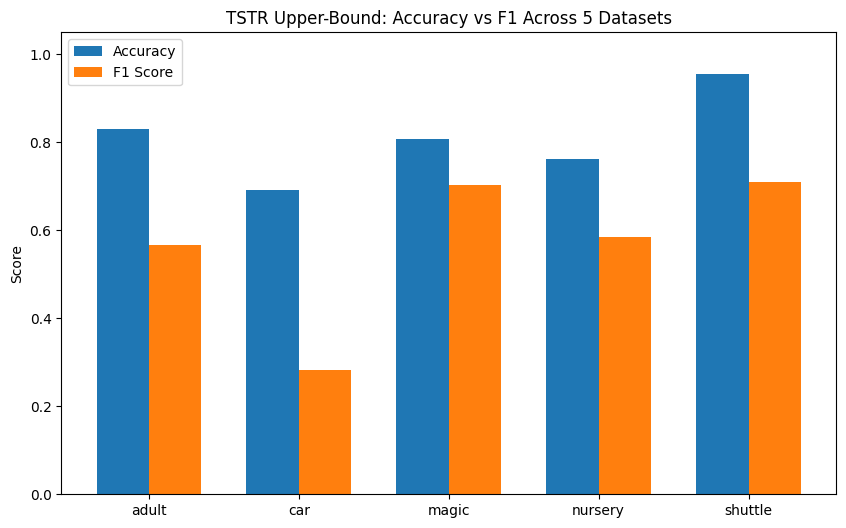

In [33]:
import numpy as np
import matplotlib.pyplot as plt

datasets = results_df["dataset"]
accuracy = results_df["accuracy"]
f1 = results_df["f1"]

x = np.arange(len(datasets))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, accuracy, width, label="Accuracy")
plt.bar(x + width/2, f1, width, label="F1 Score")

plt.xticks(x, datasets)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("TSTR Upper-Bound: Accuracy vs F1 Across 5 Datasets")
plt.legend()
plt.show()
